# Titanic Dataset — Data Cleaning & Exploratory Data Analysis

**Objective:** Perform data cleaning and exploratory data analysis (EDA) on the Titanic dataset, explore the relationships between variables, and identify the patterns and trends that shaped passenger survival.

Built for the **Prodigy InfoTech Data Science Internship — Task 2** (sample dataset: [Prodigy-InfoTech/data-science-datasets, Task 2](https://github.com/Prodigy-InfoTech/data-science-datasets/tree/main/Task%202), sourced from the [Kaggle Titanic competition](https://www.kaggle.com/c/titanic/data)).

## Contents
1. Setup & Data Loading
2. Initial Data Inspection
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis
6. Multivariate Analysis
7. Key Insights & Conclusions

## Data Dictionary

| Column | Description |
|---|---|
| PassengerId | Unique identifier for each passenger |
| Survived | Survival (0 = No, 1 = Yes) |
| Pclass | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) — a proxy for socio-economic status |
| Name | Passenger name (title embedded, e.g. Mr., Mrs., Miss.) |
| Sex | Gender |
| Age | Age in years |
| SibSp | # of siblings / spouses aboard |
| Parch | # of parents / children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)

# Consistent colors used throughout the notebook
DIED, SURVIVED = '#e74c3c', '#2ecc71'
SURVIVAL_PALETTE = {0: DIED, 1: SURVIVED}

print('Libraries loaded.')

Libraries loaded.

In [2]:
df = pd.read_csv('../data/titanic.csv')
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 891 rows x 12 columns

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Initial Data Inspection

Before cleaning anything, let's understand what we're working with: data types, summary statistics, and — most importantly — where the gaps are.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.382716,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486323,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.describe(include=['object'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


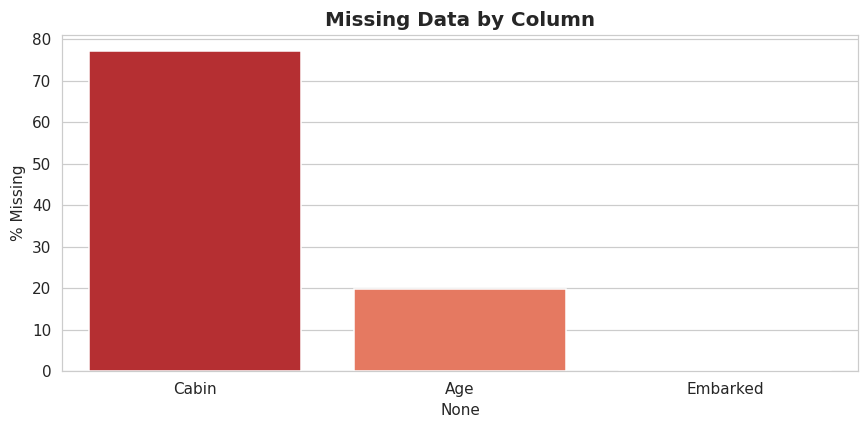

In [7]:
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_pct'], hue=missing_summary.index,
            palette='Reds_r', legend=False)
plt.ylabel('% Missing')
plt.title('Missing Data by Column')
plt.tight_layout()
plt.savefig('../images/00_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate PassengerId values: {df['PassengerId'].duplicated().sum()}")

Fully duplicated rows: 0
Duplicate PassengerId values: 0

## 3. Data Cleaning

Three columns need attention: **Age** (177 missing, ~19.9%), **Cabin** (687 missing, ~77.1%), and **Embarked** (2 missing). No duplicate rows were found, so the cleaning strategy is:

- **Age** → impute using the median age *within each `Pclass` + `Sex` group* (more precise than one global median, since typical age varies a lot by class and gender).
- **Embarked** → impute the 2 missing values with the mode (the most common port).
- **Cabin** → 77% missing means imputing actual cabin numbers would be pure guesswork. Instead, engineer two honest features — `Has_Cabin` (whether a cabin was recorded at all) and `Deck` (the first letter of the cabin, `'Unknown'` where missing) — then drop the raw column.

In [9]:
print(f"Missing Age before imputation: {df['Age'].isnull().sum()}")
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda s: s.fillna(s.median()))
print(f"Missing Age after imputation:  {df['Age'].isnull().sum()}")

Missing Age before imputation: 177
Missing Age after imputation:  0

In [10]:
mode_port = df['Embarked'].mode()[0]
print(f"Most common port of embarkation: {mode_port}  ({(df['Embarked'] == mode_port).sum()} of {df['Embarked'].notnull().sum()} known passengers)")
df['Embarked'] = df['Embarked'].fillna(mode_port)
print(f"Missing Embarked after imputation: {df['Embarked'].isnull().sum()}")

Most common port of embarkation: S  (644 of 889 known passengers)
Missing Embarked after imputation: 0

In [11]:
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df['Deck'] = df['Cabin'].str[0].fillna('Unknown')
df.drop(columns=['Cabin'], inplace=True)
df[['Has_Cabin', 'Deck']].value_counts().sort_index()

Has_Cabin  Deck   
0          Unknown    687
1          A           15
           B           47
           C           59
           D           33
           E           32
           F           13
           G            4
           T            1
Name: count, dtype: int64

In [12]:
assert df.isnull().sum().sum() == 0, "There are still missing values!"
print("No missing values remain in the dataset.")
df.isnull().sum()

No missing values remain in the dataset.

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
Deck           0
dtype: int64

## 4. Feature Engineering

A few engineered features tend to carry a lot of signal for this dataset:
- **Title** — extracted from `Name`; a strong, compact proxy for age/sex/social status.
- **FamilySize** and **IsAlone** — family structure mattered a great deal during evacuation.
- **AgeGroup** and **FareBin** — binned versions that make some relationships easier to visualize.

In [13]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [14]:
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss',
    'Mme': 'Mrs',
    'Dr': 'Rare', 'Rev': 'Rare', 'Major': 'Rare', 'Col': 'Rare', 'Don': 'Rare',
    'Lady': 'Rare', 'Sir': 'Rare', 'Capt': 'Rare', 'Countess': 'Rare', 'Jonkheer': 'Rare'
}
df['Title'] = df['Title'].replace(title_map)
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [15]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [16]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 'Adult (36-60)', 'Senior (60+)'])
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Mid', 'High', 'Very High'])
df[['Age', 'AgeGroup', 'Fare', 'FareBin']].head()

,Age,AgeGroup,Fare,FareBin
0,22.0,Young Adult (19-35),7.2500,Low
1,38.0,Adult (36-60),71.2833,Very High
2,26.0,Young Adult (19-35),7.9250,Mid
3,35.0,Young Adult (19-35),53.1000,Very High
4,35.0,Young Adult (19-35),8.0500,Mid


In [17]:
df.to_csv('../data/titanic_cleaned.csv', index=False)
print(f"Cleaned dataset saved -> data/titanic_cleaned.csv  ({df.shape[0]} rows, {df.shape[1]} columns)")
df.dtypes

Cleaned dataset saved -> data/titanic_cleaned.csv  (891 rows, 18 columns)

PassengerId       int64
Survived          int64
Pclass            int64
Name                str
Sex                 str
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Embarked            str
Has_Cabin         int64
Deck                str
Title               str
FamilySize        int64
IsAlone           int64
AgeGroup       category
FareBin        category
dtype: object

## 5. Exploratory Data Analysis

With clean data and a few new features in hand, let's explore. We'll move from univariate → bivariate → multivariate, always keeping an eye on `Survived`, the outcome we care about most.

### 5.1 Survival Overview

Overall survival rate: 38.27%  (341 of 891 passengers)

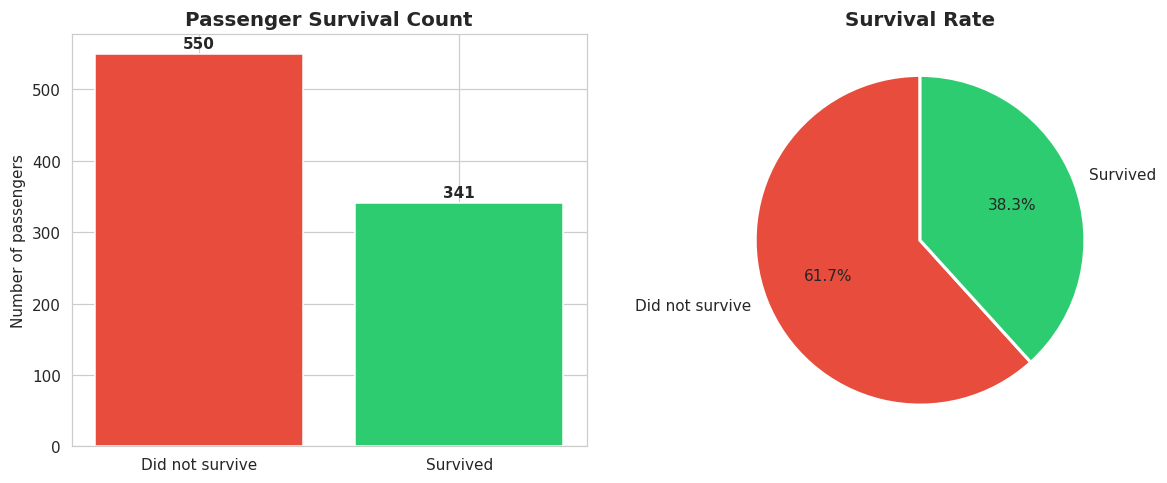

In [18]:
survival_rate = df['Survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.2f}%  ({df['Survived'].sum()} of {len(df)} passengers)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

counts = df['Survived'].value_counts().sort_index()
axes[0].bar(['Did not survive', 'Survived'], counts.values, color=[DIED, SURVIVED])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold')
axes[0].set_title('Passenger Survival Count')
axes[0].set_ylabel('Number of passengers')

axes[1].pie(counts.values, labels=['Did not survive', 'Survived'], colors=[DIED, SURVIVED],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Survival Rate')

plt.tight_layout()
plt.savefig('../images/01_survival_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Passenger Demographics

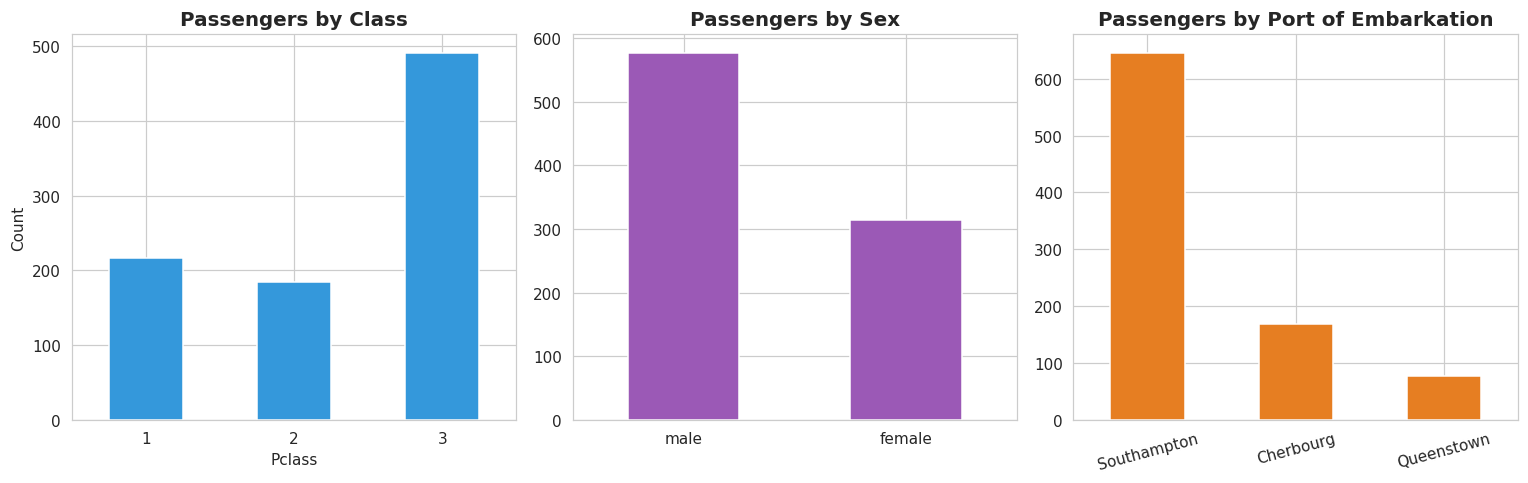

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

df['Pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Passengers by Class')
axes[0].set_xlabel('Pclass')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Sex'].value_counts().plot(kind='bar', ax=axes[1], color='#9b59b6')
axes[1].set_title('Passengers by Sex')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

df['Embarked'].map({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}).value_counts().plot(
    kind='bar', ax=axes[2], color='#e67e22')
axes[2].set_title('Passengers by Port of Embarkation')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../images/02_demographics_overview.png', dpi=150, bbox_inches='tight')
plt.show()

Fare is heavily right-skewed (skew = 4.79): most tickets were cheap, but a handful of first-class fares exceed $500.

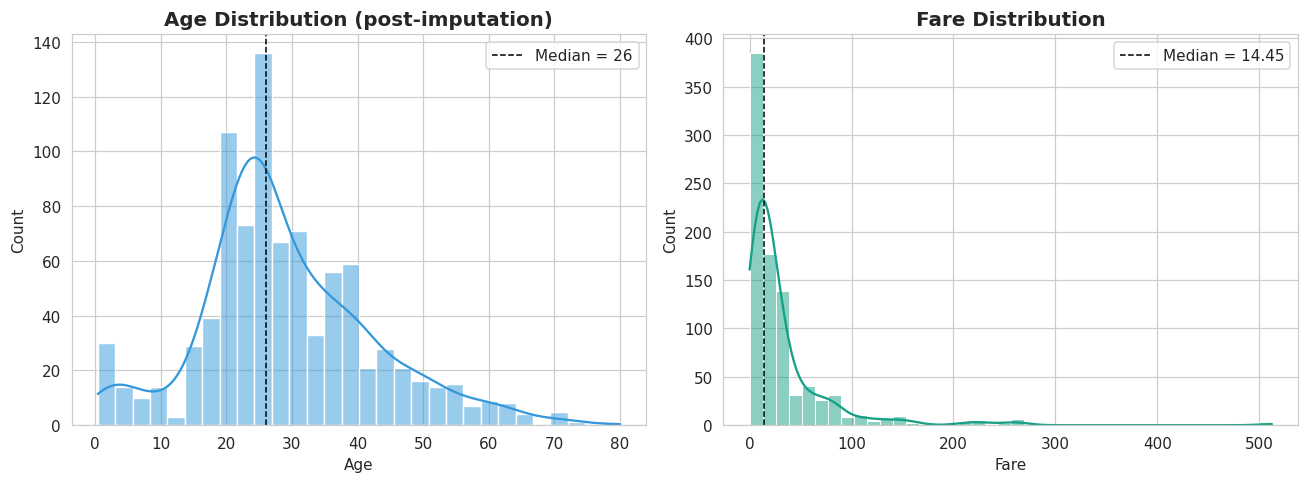

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df['Age'], bins=30, kde=True, color='#3498db', ax=axes[0])
axes[0].axvline(df['Age'].median(), color='black', linestyle='--', linewidth=1,
                label=f"Median = {df['Age'].median():.0f}")
axes[0].set_title('Age Distribution (post-imputation)')
axes[0].legend()

sns.histplot(df['Fare'], bins=40, kde=True, color='#16a085', ax=axes[1])
axes[1].axvline(df['Fare'].median(), color='black', linestyle='--', linewidth=1,
                label=f"Median = {df['Fare'].median():.2f}")
axes[1].set_title('Fare Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/03_age_fare_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fare is heavily right-skewed (skew = {df['Fare'].skew():.2f}): most tickets were cheap, "
      f"but a handful of first-class fares exceed $500.")

### 5.3 Survival vs. Sex

The *"women and children first"* evacuation protocol should show up clearly here.

Sex
female    73.89
male      18.89
Name: Survived, dtype: float64

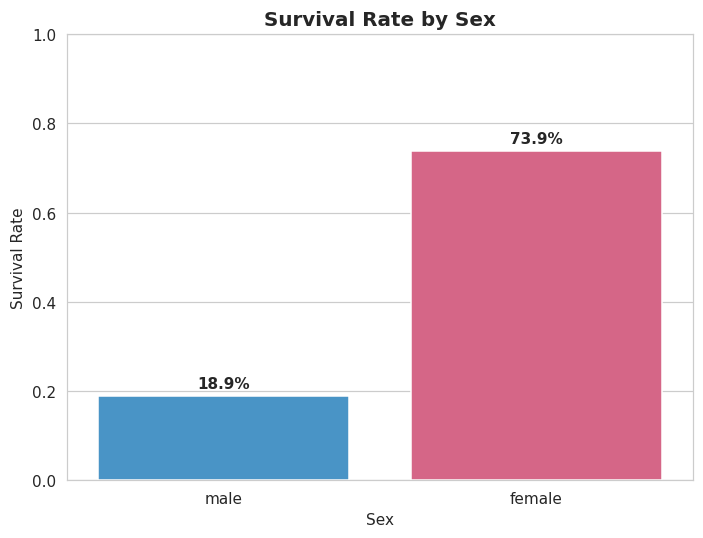

In [21]:
sex_survival = (df.groupby('Sex')['Survived'].mean() * 100).round(2)
print(sex_survival)

plt.figure(figsize=(6.5, 5))
ax = sns.barplot(x='Sex', y='Survived', data=df, hue='Sex',
                  palette={'female': '#e75480', 'male': '#3498db'}, legend=False, errorbar=None)
ax.set_ylim(0, 1)
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Sex')
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f'{v*100:.1f}%', padding=3, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/04_survival_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Survival vs. Passenger Class

Pclass
1    62.96
2    47.28
3    24.03
Name: Survived, dtype: float64

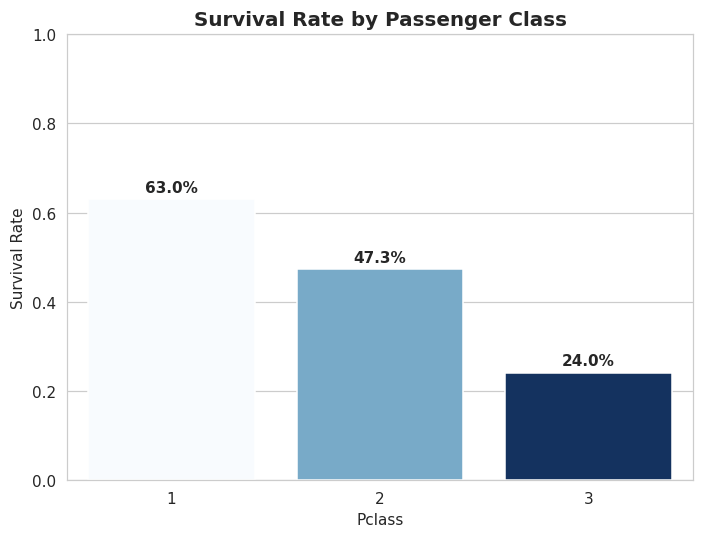

In [22]:
pclass_survival = (df.groupby('Pclass')['Survived'].mean() * 100).round(2)
print(pclass_survival)

plt.figure(figsize=(6.5, 5))
ax = sns.barplot(x='Pclass', y='Survived', data=df, hue='Pclass', palette='Blues', legend=False, errorbar=None)
ax.set_ylim(0, 1)
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Passenger Class')
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f'{v*100:.1f}%', padding=3, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/05_survival_by_pclass.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Survival vs. Port of Embarkation

Embarked
C    55.36
Q    37.66
S    33.90
Name: Survived, dtype: float64
Cherbourg passengers survived at a notably higher rate -- largely because a much bigger
share of them travelled in 1st class (confirmed in the multivariate section below).

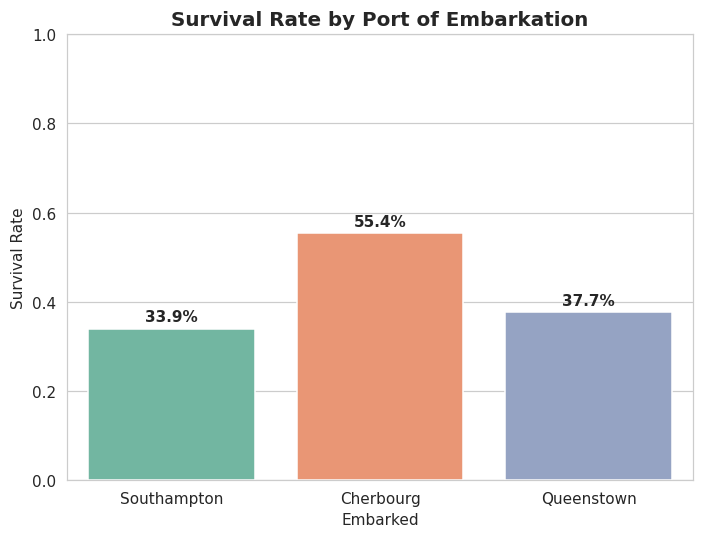

In [23]:
embarked_survival = (df.groupby('Embarked')['Survived'].mean() * 100).round(2)
print(embarked_survival)

plt.figure(figsize=(6.5, 5))
order = ['S', 'C', 'Q']
ax = sns.barplot(x='Embarked', y='Survived', data=df, order=order, hue='Embarked',
                  palette='Set2', legend=False, errorbar=None)
ax.set_ylim(0, 1)
ax.set_xticklabels(['Southampton', 'Cherbourg', 'Queenstown'])
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Port of Embarkation')
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f'{v*100:.1f}%', padding=3, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/06_survival_by_embarked.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cherbourg passengers survived at a notably higher rate -- largely because a much bigger")
print("share of them travelled in 1st class (confirmed in the multivariate section below).")

### 5.6 Age vs. Survival

Survival rate for children (age <= 12): 58.0%
Survival rate for young adults (19-35):  35.6%

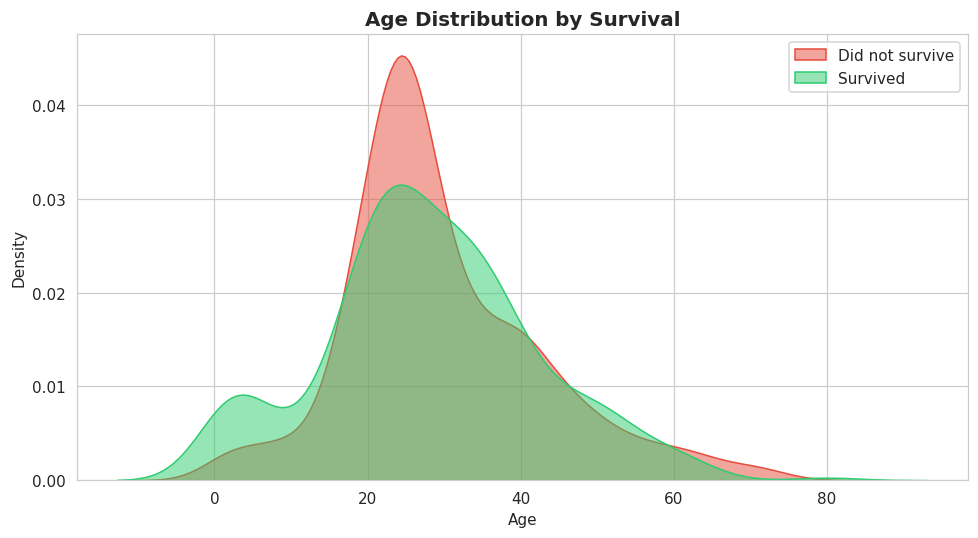

In [24]:
plt.figure(figsize=(9, 5))
sns.kdeplot(df.loc[df['Survived'] == 0, 'Age'], fill=True, color=DIED, label='Did not survive', alpha=0.5)
sns.kdeplot(df.loc[df['Survived'] == 1, 'Age'], fill=True, color=SURVIVED, label='Survived', alpha=0.5)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
plt.savefig('../images/07_age_distribution_by_survival.png', dpi=150, bbox_inches='tight')
plt.show()

child_survival = df.loc[df['Age'] <= 12, 'Survived'].mean() * 100
young_adult_survival = df.loc[df['Age'].between(19, 35), 'Survived'].mean() * 100
print(f"Survival rate for children (age <= 12): {child_survival:.1f}%")
print(f"Survival rate for young adults (19-35):  {young_adult_survival:.1f}%")

### 5.7 Fare vs. Survival

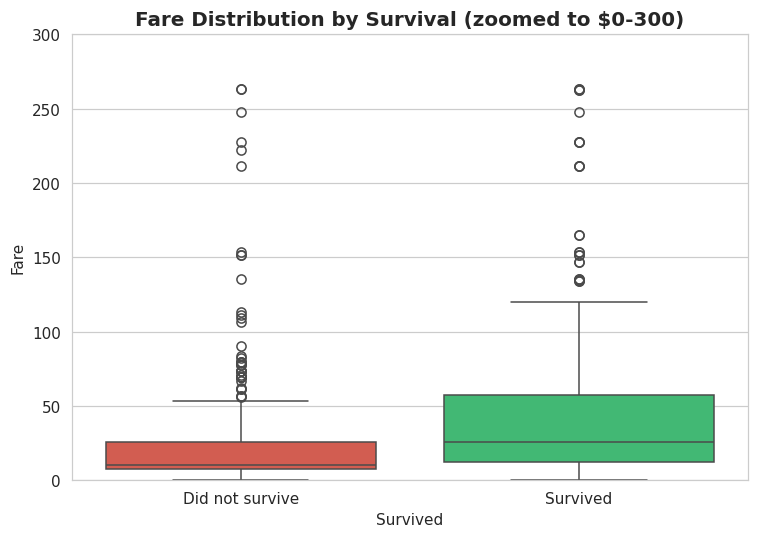

Survived
0    10.5
1    26.0
Name: Fare, dtype: float64

In [25]:
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x='Survived', y='Fare', data=df, hue='Survived', palette=SURVIVAL_PALETTE, legend=False)
ax.set_xticklabels(['Did not survive', 'Survived'])
ax.set_ylim(0, 300)  # zoom past the small number of extreme outliers for readability
ax.set_title('Fare Distribution by Survival (zoomed to $0-300)')
plt.tight_layout()
plt.savefig('../images/08_fare_by_survival.png', dpi=150, bbox_inches='tight')
plt.show()

df.groupby('Survived')['Fare'].median()

### 5.8 Family Size & Cabin Record vs. Survival

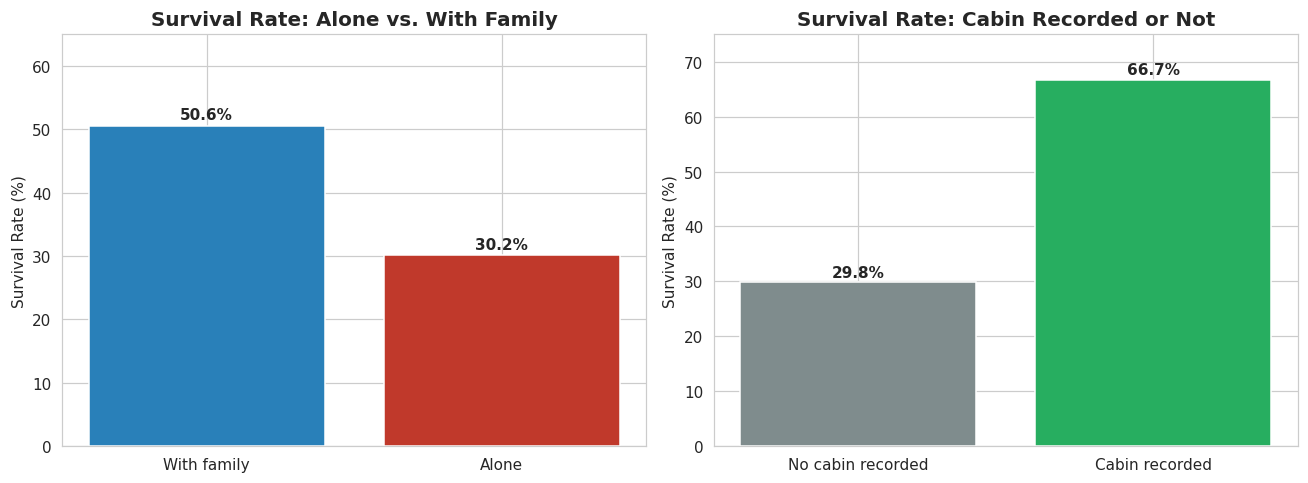

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

alone_survival = (df.groupby('IsAlone')['Survived'].mean() * 100)
axes[0].bar(['With family', 'Alone'], alone_survival.reindex([0, 1]).values, color=['#2980b9', '#c0392b'])
for i, v in enumerate(alone_survival.reindex([0, 1]).values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Survival Rate: Alone vs. With Family')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 65)

cabin_survival = (df.groupby('Has_Cabin')['Survived'].mean() * 100)
axes[1].bar(['No cabin recorded', 'Cabin recorded'], cabin_survival.reindex([0, 1]).values, color=['#7f8c8d', '#27ae60'])
for i, v in enumerate(cabin_survival.reindex([0, 1]).values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Survival Rate: Cabin Recorded or Not')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 75)

plt.tight_layout()
plt.savefig('../images/09_family_and_cabin_survival.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
family_bucket = pd.cut(df['FamilySize'], bins=[0, 1, 4, 20],
                        labels=['Alone (1)', 'Small family (2-4)', 'Large family (5+)'])
(df.groupby(family_bucket, observed=True)['Survived'].agg(['mean', 'count'])
   .rename(columns={'mean': 'Survival Rate', 'count': 'Passengers'})
   .assign(**{'Survival Rate': lambda d: (d['Survival Rate'] * 100).round(2)}))

,Survival Rate,Passengers
FamilySize,,
Alone (1),30.17,537
Small family (2-4),57.88,292
Large family (5+),16.13,62


### 5.9 Survival vs. Title

In [28]:
title_survival = (df.groupby('Title')['Survived'].agg(['mean', 'count']).sort_values('mean', ascending=False))
title_survival['mean'] = (title_survival['mean'] * 100).round(2)
title_survival.columns = ['Survival Rate (%)', 'Count']
title_survival

,Survival Rate (%),Count
Title,,
Mrs,79.37,126
Miss,69.73,185
Master,57.50,40
Rare,34.78,23
Mr,15.67,517


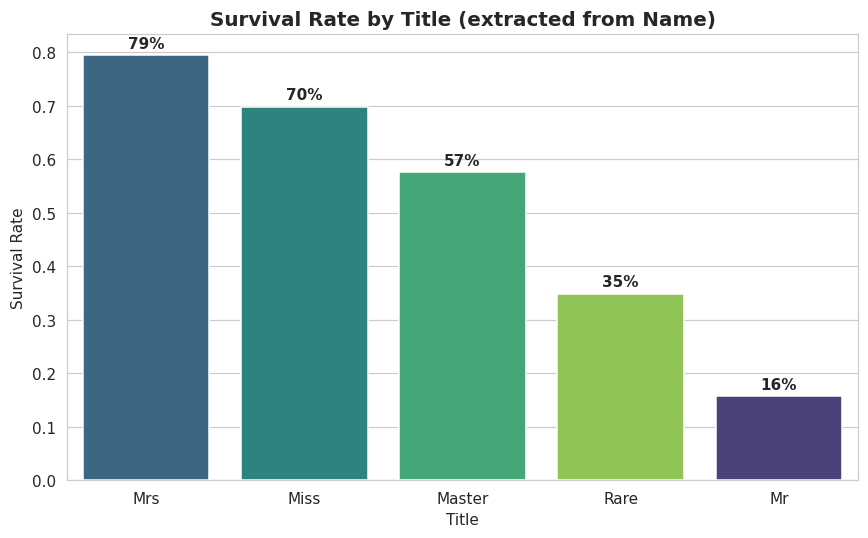

In [29]:
plt.figure(figsize=(8, 5))
order = title_survival.index
ax = sns.barplot(x='Title', y='Survived', data=df, order=order, hue='Title',
                  palette='viridis', legend=False, errorbar=None)
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Title (extracted from Name)')
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f'{v*100:.0f}%', padding=3, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/10_title_survival.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Multivariate Analysis

Single-variable relationships only tell part of the story. Class and sex, in particular, interact strongly with each other.

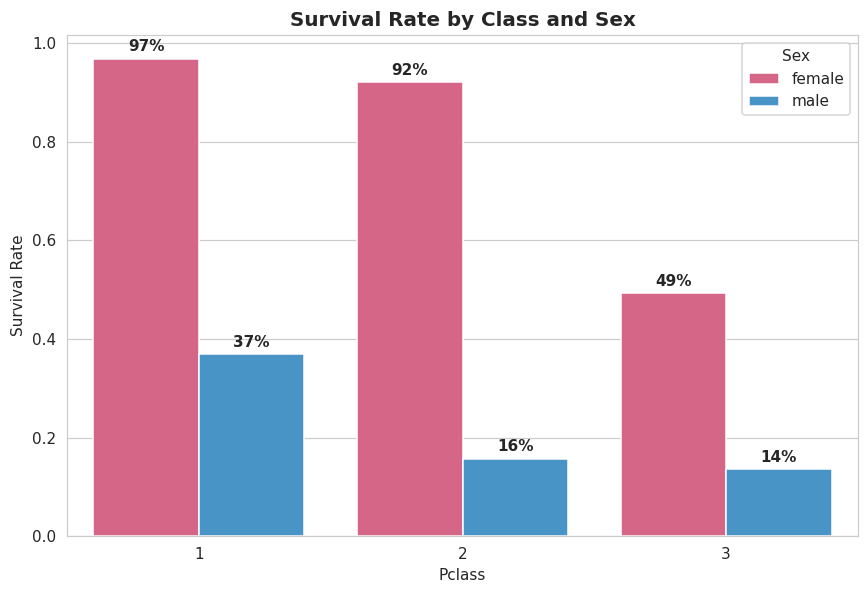

Sex,female,male
Pclass,,
1,96.8,36.9
2,92.1,15.7
3,49.3,13.5


In [30]:
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df,
                  palette={'female': '#e75480', 'male': '#3498db'}, errorbar=None)
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Class and Sex')
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f'{v*100:.0f}%', padding=3, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/11_pclass_sex_survival.png', dpi=150, bbox_inches='tight')
plt.show()

pd.pivot_table(df, index='Pclass', columns='Sex', values='Survived', aggfunc='mean').round(3) * 100

Strongest correlations with Survived:

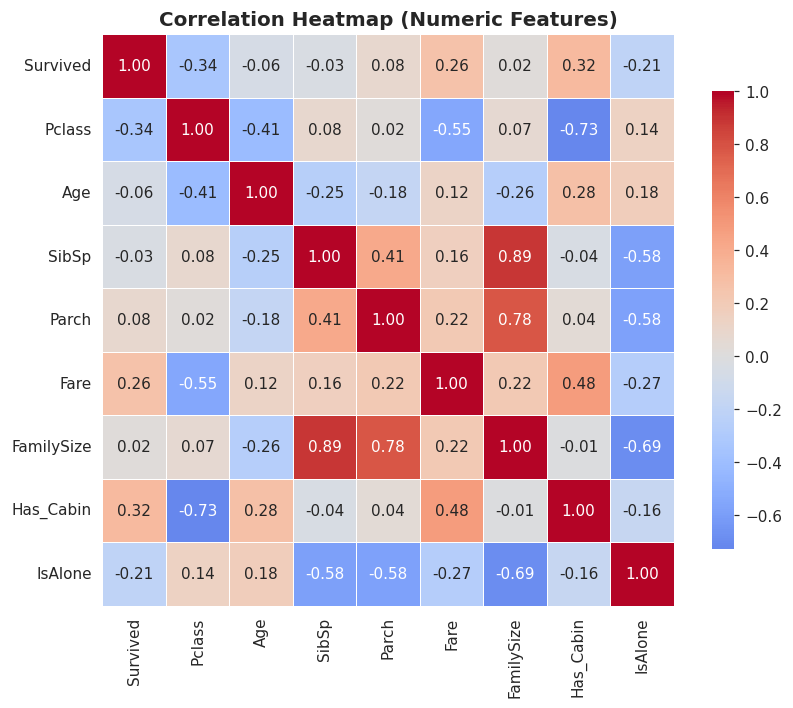

Pclass       -0.341
Has_Cabin     0.318
Fare          0.259
IsAlone      -0.205
Parch         0.083
Age          -0.058
SibSp        -0.034
FamilySize    0.018
Name: Survived, dtype: float64

In [31]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Has_Cabin', 'IsAlone']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.savefig('../images/12_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Strongest correlations with Survived:")
corr['Survived'].drop('Survived').sort_values(key=abs, ascending=False).round(3)

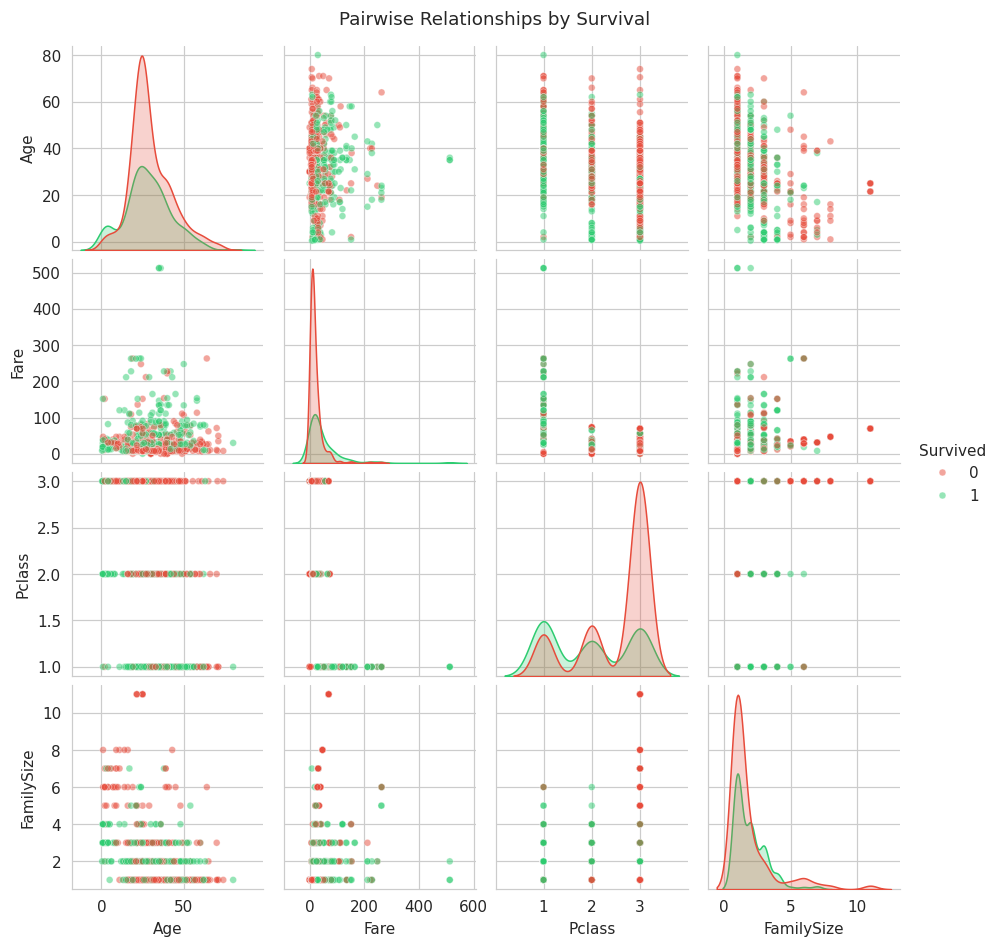

In [32]:
pairplot_cols = ['Age', 'Fare', 'Pclass', 'FamilySize', 'Survived']
g = sns.pairplot(df[pairplot_cols], hue='Survived', palette=SURVIVAL_PALETTE, diag_kind='kde',
                  plot_kws={'alpha': 0.5, 's': 20}, height=2.1)
g.fig.suptitle('Pairwise Relationships by Survival', y=1.02)
g.savefig('../images/13_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Key Insights & Conclusions

In [33]:
summary = pd.DataFrame({
    'Segment': ['Overall', 'Female', 'Male', 'Class 1', 'Class 2', 'Class 3',
                'Child (<=12)', 'Alone', 'Small family (2-4)', 'Large family (5+)',
                'Has cabin', 'No cabin'],
    'Survival Rate (%)': [
        df['Survived'].mean() * 100,
        df.loc[df['Sex'] == 'female', 'Survived'].mean() * 100,
        df.loc[df['Sex'] == 'male', 'Survived'].mean() * 100,
        df.loc[df['Pclass'] == 1, 'Survived'].mean() * 100,
        df.loc[df['Pclass'] == 2, 'Survived'].mean() * 100,
        df.loc[df['Pclass'] == 3, 'Survived'].mean() * 100,
        df.loc[df['Age'] <= 12, 'Survived'].mean() * 100,
        df.loc[df['FamilySize'] == 1, 'Survived'].mean() * 100,
        df.loc[df['FamilySize'].between(2, 4), 'Survived'].mean() * 100,
        df.loc[df['FamilySize'] >= 5, 'Survived'].mean() * 100,
        df.loc[df['Has_Cabin'] == 1, 'Survived'].mean() * 100,
        df.loc[df['Has_Cabin'] == 0, 'Survived'].mean() * 100,
    ]
})
summary['Survival Rate (%)'] = summary['Survival Rate (%)'].round(2)
summary

,Segment,Survival Rate (%)
0,Overall,38.27
1,Female,73.89
2,Male,18.89
3,Class 1,62.96
4,Class 2,47.28
5,Class 3,24.03
6,Child (<=12),57.97
7,Alone,30.17
8,Small family (2-4),57.88
9,Large family (5+),16.13


Bringing together everything explored above, this dataset tells a fairly clear story about who survived the Titanic disaster and why:

1. **Sex was the single strongest predictor of survival.** Women survived at **73.9%** vs. **18.9%** for men — a 55-point gap, far larger than any other single factor. This matches the historical "women and children first" evacuation protocol.

2. **Passenger class mattered almost as much.** Survival fell in a clean, monotonic staircase from 1st class (**63.0%**) to 2nd (**47.3%**) to 3rd (**24.0%**). Wealthier passengers had cabins closer to the boat deck and, very likely, more consistent access to lifeboats.

3. **Age reinforced the "children first" pattern.** Children 12 and under survived at **58.0%**, well above the **35.6%** rate for young adults (19-35) — though Age alone is a much weaker predictor than Sex or Class.

4. **Family size had a "sweet spot."** Passengers travelling completely alone survived at **30.2%**, and those in large families of 5+ survived worst of all at **16.1%** (large groups struggled to stay together and reach a boat in time). Small families of 2-4 did best, at **57.9%**.

5. **Fare and cabin records echo the class effect.** Passengers with a recorded cabin number (mostly 1st/2nd class) survived at **66.7%** vs. **29.8%** for those without one, and median fare was noticeably higher among survivors — fare is itself largely a proxy for `Pclass`.

6. **Titles extracted from `Name` echo all of the above at once.** `Mrs` (**79.4%**) and `Miss` (**69.7%**) survived best, `Master` — young boys (**57.5%**) — next, then the mixed `Rare` titles (**34.8%**), with `Mr` surviving worst by far (**15.7%**). A single text field almost fully reconstructs the Sex + Age story.

7. **Port of embarkation looks meaningful (Cherbourg 55.4% vs. Southampton 33.9%) but is largely a confound of class** — the multivariate breakdown shows Cherbourg simply carried a much larger share of 1st-class passengers.

**Bottom line:** survival on the Titanic was overwhelmingly shaped by *who you were* (sex, age) and *where you could afford to be on the ship* (class, fare, cabin) — a sobering, data-backed illustration of how the "women and children first" protocol interacted with existing social stratification during the evacuation.

### Possible next steps
- Train a classification model (logistic regression / random forest) using the engineered features (`Title`, `FamilySize`, `IsAlone`, `Has_Cabin`, `Deck`) to predict `Survived`.
- Dig into the `Deck` feature more closely against `Pclass` to see how cabin location on the ship related to survival.
- Compare this exploratory approach against the original Kaggle test set for a full train / predict / submit pipeline.

---
*Notebook generated as part of the Prodigy InfoTech Data Science Internship — Task 2.*